<a href="https://colab.research.google.com/github/Deshantheekshana524/ML-Tutorials/blob/main/notebooks/Penguins_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# import data from google drive
penguins_data = pd.read_csv('/content/drive/MyDrive/ML datasets/penguins.csv')

# removing rows with missing values
penguins_data = penguins_data.dropna()

In [3]:
# defining target and feature variables
x = penguins_data.drop('species', axis = 1)
y = penguins_data['species']

# encoding categorical variables
x = pd.get_dummies(x, drop_first = True)

In [4]:
# training and testing set spliting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 524)

In [5]:
# random forest with hyperparameter tuning

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# parameter distribution
param_grid = {
    'n_estimators': [50, 100, 200, 250, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

# randomized grid search cv
random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 524),
    param_distributions = param_grid,
    cv = cv,
    scoring = 'accuracy',
    n_iter = 25,
    n_jobs = -1,
    random_state = 524
)

# fitting the data into random search
random_search.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=524),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 250,
                                                         300]},
                   random_state=524, scoring='accuracy')

In [6]:
# finding the best model
best_rf = random_search.best_estimator_

In [7]:
# model evaluation

# predicting with the best model
y_pred = best_rf.predict(x_test)

# accuracy score
print('accuracy:', round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))


accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        24
   Chinstrap       1.00      1.00      1.00        15
      Gentoo       1.00      1.00      1.00        28

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



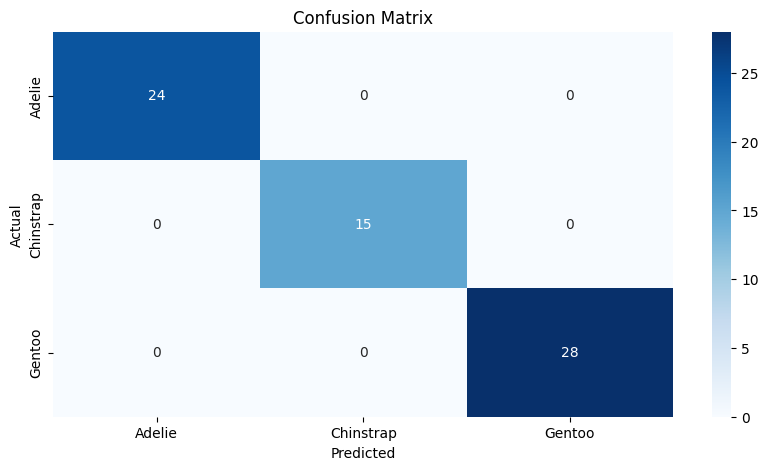

In [8]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10, 5))
sns.heatmap(cm, annot = True, fmt ="d", cmap = "Blues",
    xticklabels = best_rf.classes_,
    yticklabels = best_rf.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 1.0, 'feature importance plot')

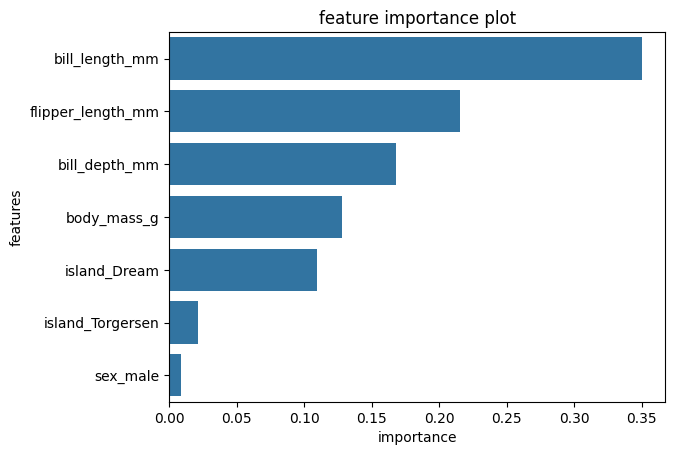

In [10]:
# feature importance plot
feature_importances = pd.DataFrame(best_rf.feature_importances_, index = x.columns, columns = ['importance']).sort_values('importance', ascending = False)
sns.barplot(data = feature_importances, x = 'importance', y = feature_importances.index)
plt.ylabel('features')
plt.title('feature importance plot')

The Random Forest model primarily relies on bill length, flipper length, and bill depth for classification, while island features have moderate influence and sex has minimal impact.